# INF161 Prosjekt

In [1]:
# Data handling og manipulering
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.dummy import DummyRegressor

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import root_mean_squared_error

import pickle

pd.set_option('display.max_columns', None)  # Viser alle kolonner i tabellen


# Datatilbredning

## Dempgraphic

In [2]:
df_demographic = pd.read_csv("raw_data/demographic.csv")

Mapper income slik at det det numeriske verider

In [3]:
income_mapping = {
    '$11-$25k': 1,
    'under $11k': 0,
    '$25k-$50k': 2,
    '$50k-$75k': 3,
    'above $75k': 4
}

df_demographic['inntekt'] = df_demographic['inntekt'].map(income_mapping)

## Hospital

In [4]:
df_hospital = pd.read_csv("raw_data/hospital.csv")

Fjerner negativ oppholdslengde, da målet er å predikere oppholdslengde.

In [5]:
df_hospital = df_hospital[df_hospital['oppholdslengde'] >= 0]

## physiological

In [6]:
df_physiological = pd.read_csv("raw_data/physiological.txt", delimiter='\t')

## Severity

In [7]:
df_severity = pd.read_json("raw_data/severity.json")

Koden strukturerer df_severity slik at hver pasient får sine data på separate rader og sorteres etter pasient_id

In [8]:
df_severity = df_severity.iloc[:, 0:-1].explode(list(df_severity.columns[2:-1]))
df_severity.reset_index(drop=True, inplace=True)
df_severity=df_severity.sort_values(by=['pasient_id'], ignore_index=True)

## Merger datasett

In [9]:
df = pd.merge(df_severity, df_demographic, on='pasient_id', how='inner')

df = pd.merge(df, df_hospital, on='pasient_id', how='inner')

df = pd.merge(df, df_physiological, on='pasient_id', how='inner')


## Fjerner duplikater

Fjerner duplikater for å forhindre skjevheter i modellen

In [10]:
df = df.drop_duplicates()

## Fjerner rader med negativ alder

Fjerner rader med negativ alder for å gjøre slik at dataen er realistisk

In [11]:
df = df[df['alder'] >= 0]

## Fjerner sykdomskategorier

Fjerner det fordi informasjonen i sykdomskategori allerede finnes i sykdomsunderkategorier

In [12]:
df = df.drop([
   'sykdomskategori_id', 'sykdomskategori'
], axis=1)

## NaN-verdier

Setter inn anbefalte verider fra: https://archive.ics.uci.edu/dataset/880/support2

In [13]:
df['serumalbumin'].fillna(3.5, inplace=True)
df['lungefunksjon'].fillna(333.3, inplace=True)
df['bilirubin'].fillna(1.01, inplace=True)
df['kreatinin'].fillna(1.01, inplace=True)
df['blodurea_nitrogen'].fillna(6.51, inplace=True)
df['hvite_blodlegemer'].fillna(9, inplace=True)
df['urinmengde'].fillna(2502, inplace=True)

/var/folders/1h/__q6rdbs1lqc2l3nlfz9t72m0000gn/T/ipykernel_97535/3606572185.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['serumalbumin'].fillna(3.5, inplace=True)
/var/folders/1h/__q6rdbs1lqc2l3nlfz9t72m0000gn/T/ipykernel_97535/3606572185.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

## Dropper adl_pasient og adl_stedfortreder

Fjerner adl_pasient siden dette er informasjon som kom på dag 7 og det er ikke relevant når vi skal predikere fra dag 1. Fjerner adl_stedfortreder fordi den har veldig høy verdi av missing values. 

In [14]:
df.drop(['adl_pasient', 'adl_stedfortreder'], axis=1, inplace=True)

## Fjerner DNR status

DNR-status fjernes, da den ikke har direkte innvirkning på oppholdslengden

In [15]:
df.drop(['dnr_status'], axis=1, inplace=True)

## Fjerner verdier som er målt på dag 7

Siden vi skal predikere fra dag 1, har verdier målt på dag 7 ingen innvirkning

In [16]:
df.drop('bilirubin', axis=1, inplace= True)

## Fjerner dødsfall, sykehusdød og pasient_id

Fjerner dødsfall og sykehusdød fordi de viser kjente utfall som kan påvirke prediksjonene
Fjerner pasient_id da det kun er en indeksering

In [17]:
df.drop('dødsfall', axis = 1, inplace = True)
df.drop('sykehusdød', axis=1, inplace = True)
df.drop('pasient_id', axis=1, inplace = True)

## Deler opp i treningsdata, testdata og valideringsdata

In [18]:
X = df.drop(columns=['oppholdslengde']) #feature
y = df['oppholdslengde'] #target-sett

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

## OneHotEncoder

Jeg OneHotEncoder for å konvertere kategoriske variabler til numeriske verdier, slik at de kan brukes i modellen. Etter at OneHotEncoder er tilpasset X_train, transformerer jeg både X_train, X_val, og X_test for å sikre konsistente kolonner på tvers av datasett. Til slutt konverterer jeg alle verdiene til float-format for å sikre at de fungerer med modeller som krever numeriske data

In [19]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')

categorical_columns = ['sykdom_underkategori', 'kreft', 'kjønn', 'etnisitet']

ohe.fit(X_train[categorical_columns])

X_train = pd.concat([X_train.drop(columns=categorical_columns).reset_index(drop=True), 
                     ohe.transform(X_train[categorical_columns]).reset_index(drop=True)], axis=1)

X_val = pd.concat([X_val.drop(columns=categorical_columns).reset_index(drop=True), 
                   ohe.transform(X_val[categorical_columns]).reset_index(drop=True)], axis=1)

X_test = pd.concat([X_test.drop(columns=categorical_columns).reset_index(drop=True), 
                    ohe.transform(X_test[categorical_columns]).reset_index(drop=True)], axis=1)


X_train = X_train.astype(float)
X_val = X_val.astype(float)
X_test = X_test.astype(float)


# Utforskende dataanalyse og visualisering

## Statistisk beskrivelse av variablene i datasettet 

In [20]:
X_train_with_target = X_train.copy()
X_train_with_target['oppholdslengde'] = y_train.values 

In [21]:
X_train_with_target.describe()

,antall_komorbiditeter,koma_score,fysiologisk_score,apache_fysiologisk_score,overlevelsesestimat_2mnd,overlevelsesestimat_6mnd,diabetes,demens,lege_overlevelsesestimat_2mnd,lege_overlevelsesestimat_6mnd,alder,utdanning,inntekt,blodtrykk,hvite_blodlegemer,hjertefrekvens,respirasjonsfrekvens,kroppstemperatur,lungefunksjon,serumalbumin,kreatinin,natrium,blod_ph,glukose,blodurea_nitrogen,urinmengde,sykdom_underkategori_ARF/MOSF w/Sepsis,sykdom_underkategori_CHF,sykdom_underkategori_COPD,sykdom_underkategori_Cirrhosis,sykdom_underkategori_Colon Cancer,sykdom_underkategori_Coma,sykdom_underkategori_Lung Cancer,sykdom_underkategori_MOSF w/Malig,kreft_metastatic,kreft_no,kreft_yes,kjønn_female,kjønn_male,etnisitet_asian,etnisitet_black,etnisitet_hispanic,etnisitet_other,etnisitet_white,etnisitet_nan,oppholdslengde
count,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,4404.000000,4416.000000,5410.000000,4433.000000,2598.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,4080.000000,2743.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.00000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000
mean,1.840850,12.202957,25.603450,37.809797,0.632434,0.516665,0.191128,0.034935,0.614721,0.497405,62.815565,11.796752,0.358353,84.693438,12.340621,97.618983,23.406654,37.138702,263.188839,3.146953,1.766745,137.622921,7.413809,160.639810,20.100706,2361.892564,0.392237,0.149908,0.104251,0.051756,0.057856,0.066359,0.100555,0.077079,0.20610,0.657486,0.136414,0.434381,0.565619,0.009982,0.154713,0.031423,0.011460,0.787616,0.004806,17.909242
std,1.330555,24.629400,9.867326,20.159033,0.250074,0.254846,0.393226,0.183633,0.300615,0.304774,15.450071,3.499803,0.479609,27.808522,9.384883,31.305589,9.554365,1.266966,104.322160,0.699742,1.667329,6.032462,0.081830,88.241442,23.123185,1031.275377,0.488294,0.357014,0.305615,0.221554,0.233492,0.248931,0.300766,0.266742,0.40454,0.474594,0.343259,0.495721,0.495721,0.099417,0.361665,0.174475,0.106447,0.409033,0.069164,21.438629
min,0.000000,0.000000,1.199951,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.146000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,31.699220,12.000000,0.399963,0.099991,110.000000,6.829102,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
25%,1.000000,0.000000,19.097656,23.000000,0.497986,0.333984,0.000000,0.000000,0.400000,0.200000,52.971980,10.000000,0.000000,64.000000,7.000000,72.000000,18.000000,36.195310,178.000000,2.699707,0.899902,134.000000,7.379883,103.500000,6.510000,2071.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,6.000000
50%,2.000000,0.000000,24.000000,35.000000,0.711914,0.567993,0.000000,0.000000,0.700000,0.500000,65.078490,12.000000,0.000000,77.000000,10.398438,100.000000,24.000000,36.796880,276.187500,3.500000,1.199951,137.000000,7.419922,134.000000,6.510000,2502.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,11.000000
75%,3.000000,9.000000,30.199219,49.000000,0.824951,0.724976,0.000000,0.000000,0.900000,0.750000,74.042235,14.000000,1.000000,108.000000,15.174316,120.000000,28.000000,38.195310,333.300000,3.500000,1.899902,141.000000,7.469727,191.000000,25.000000,2502.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,20.000000
max,8.000000,100.000000,

For å undersøke forholdet mellom  de ulik variablene og oppholdslengde, har jeg laget scatterplot for alle variablene i X_train. For å kunne lage visualiseringer opp mot oppholdslengde lager jeg et df som inneholder oppholdslenge

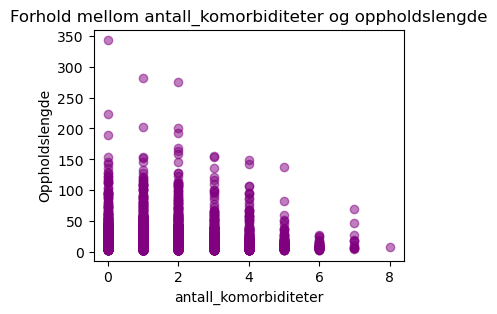

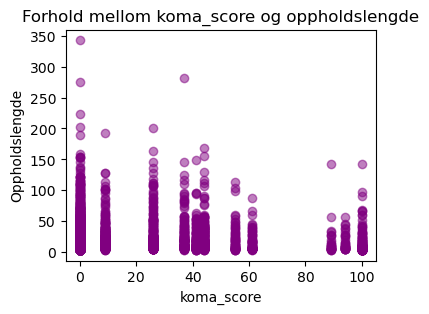

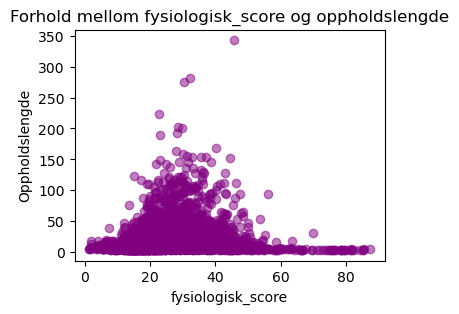

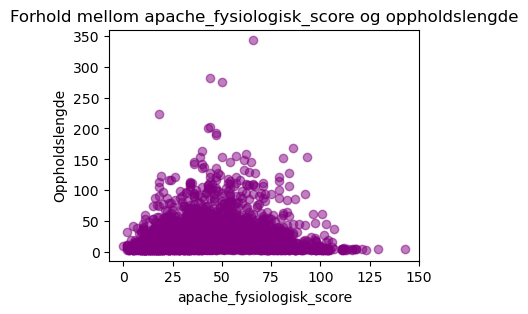

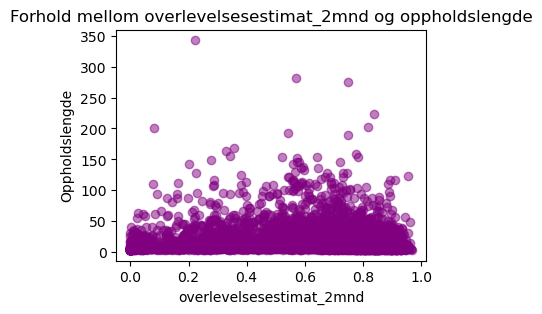

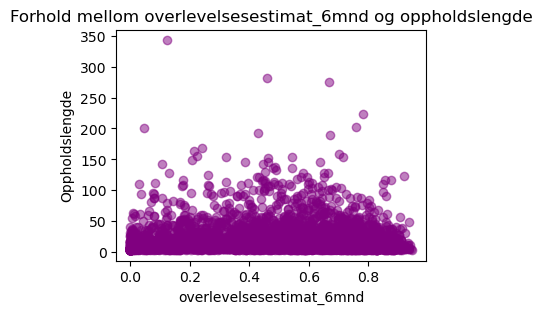

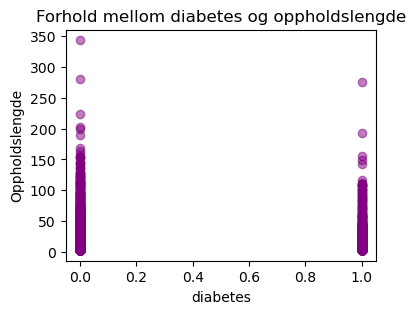

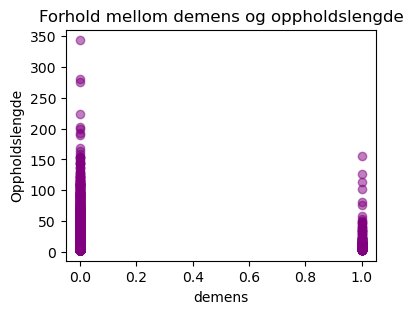

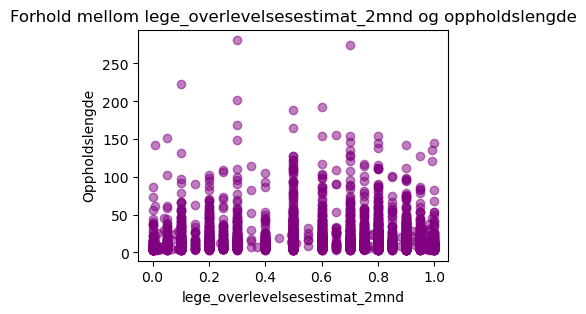

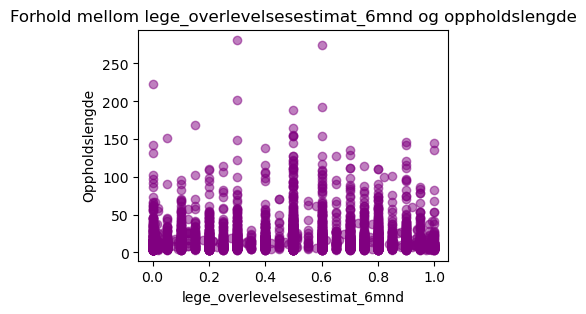

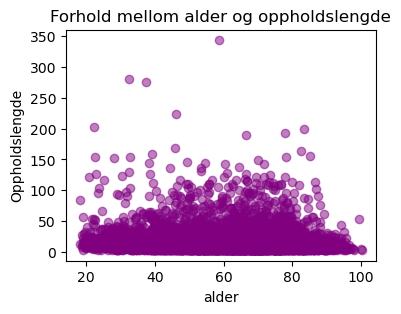

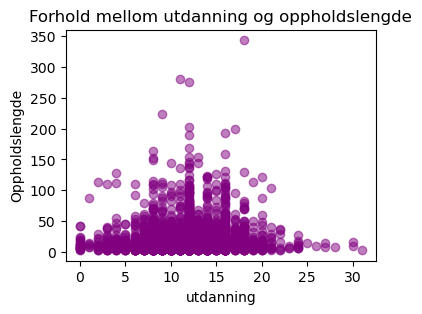

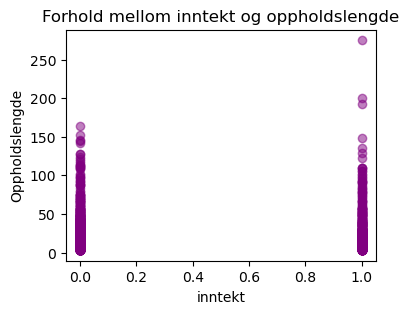

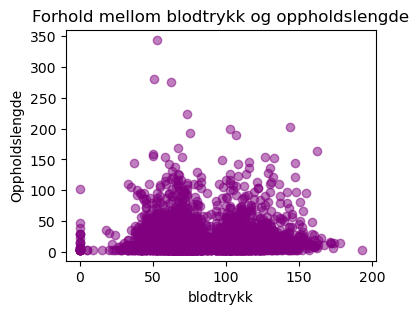

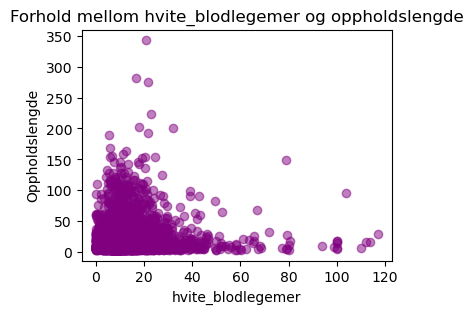

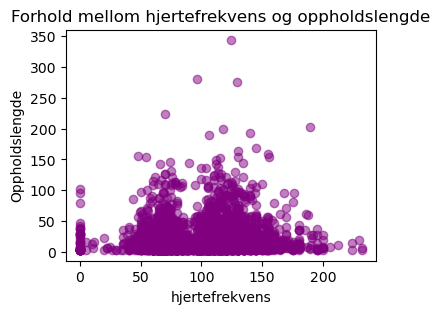

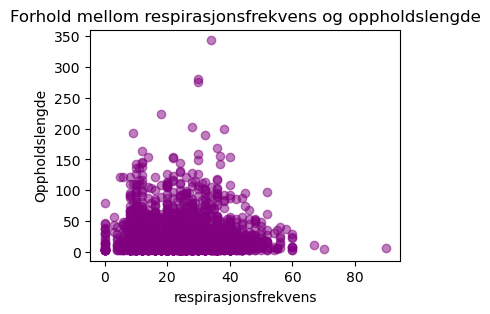

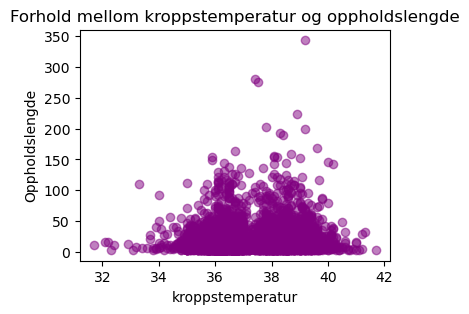

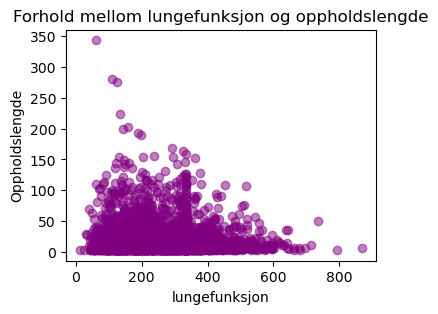

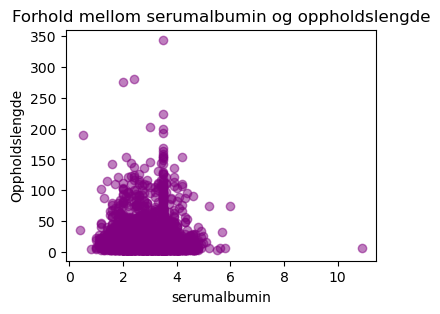

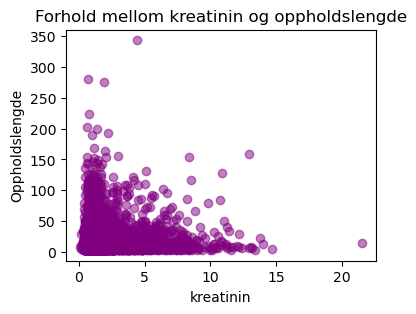

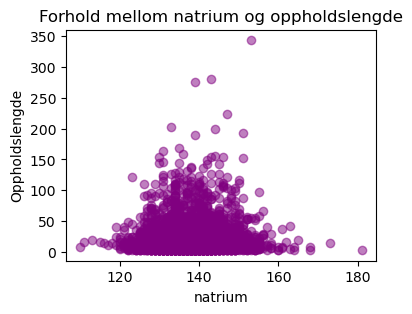

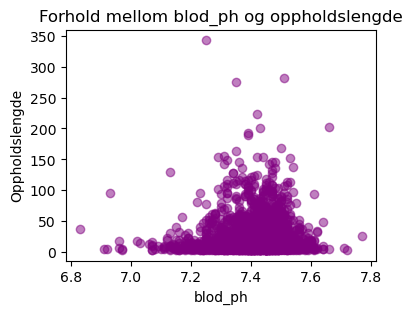

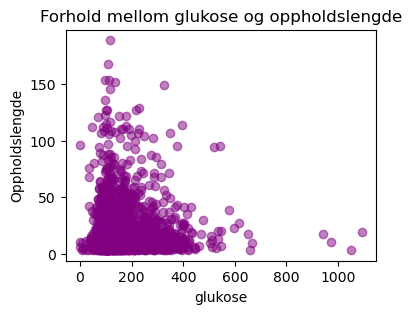

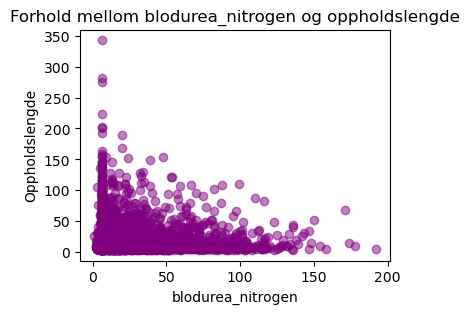

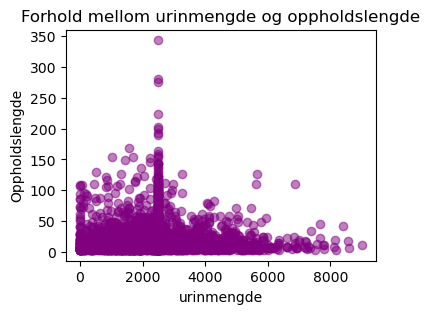

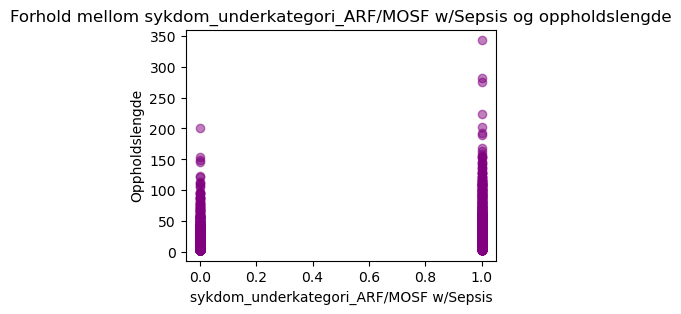

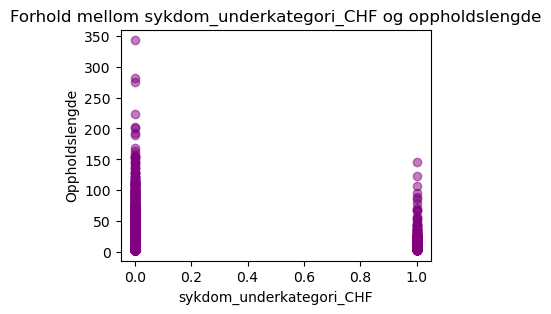

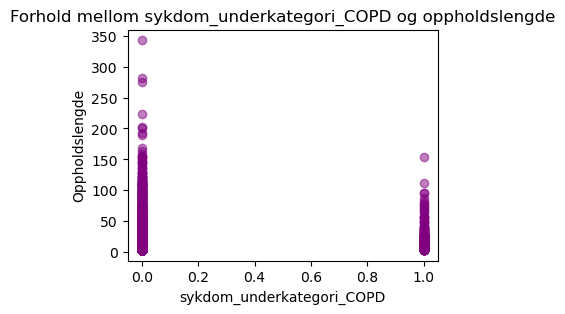

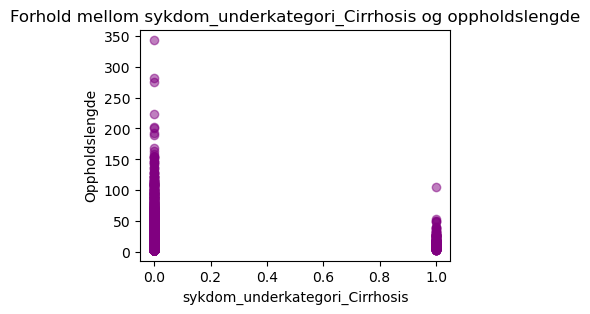

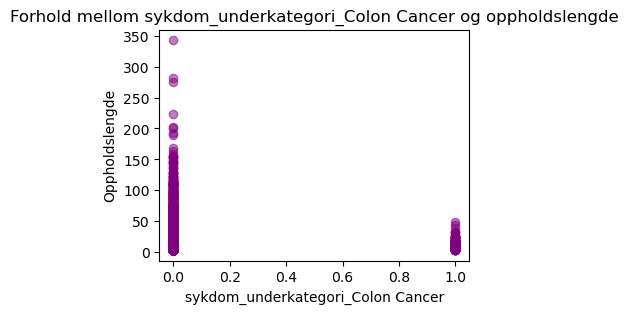

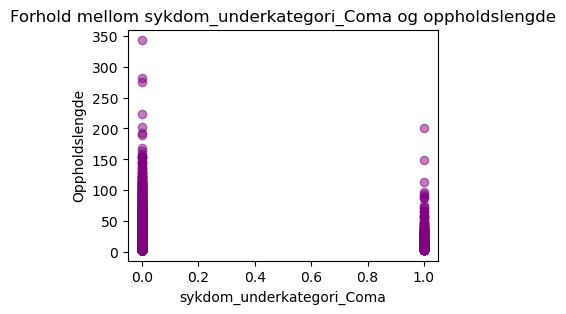

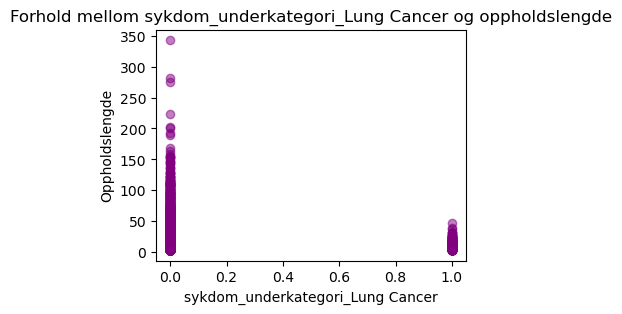

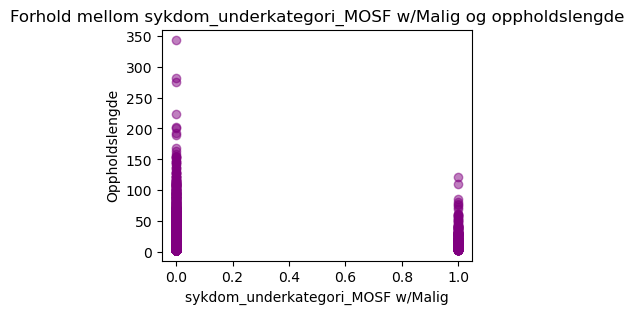

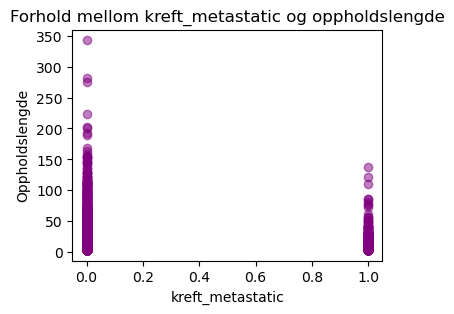

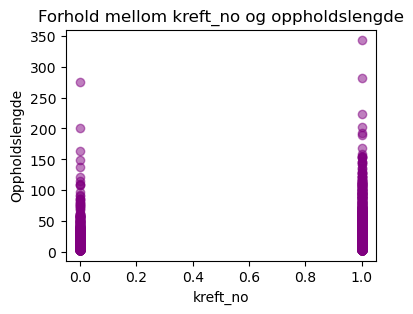

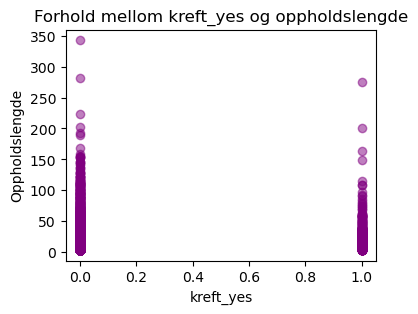

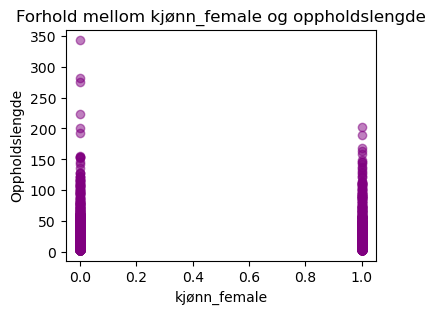

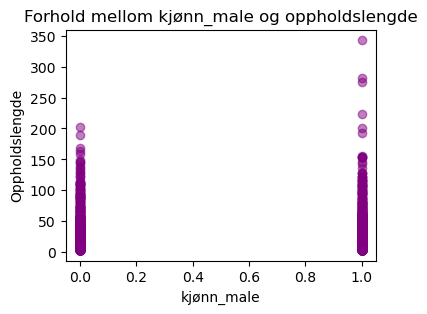

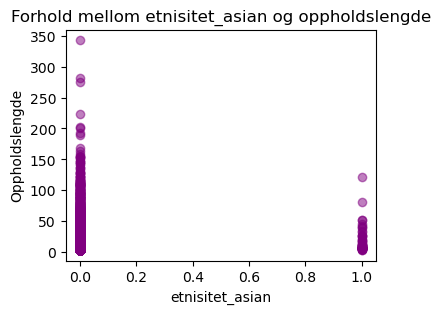

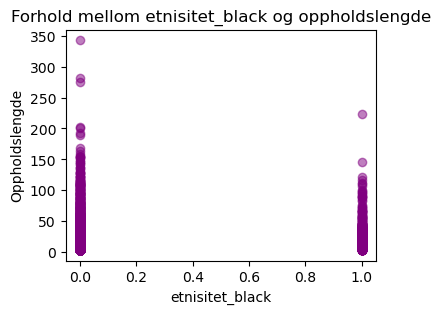

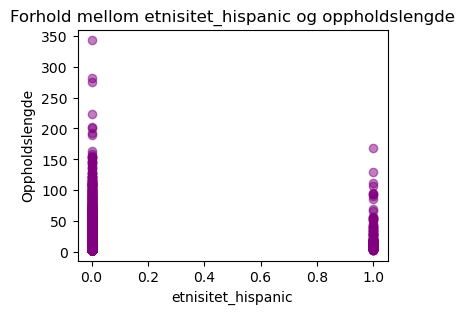

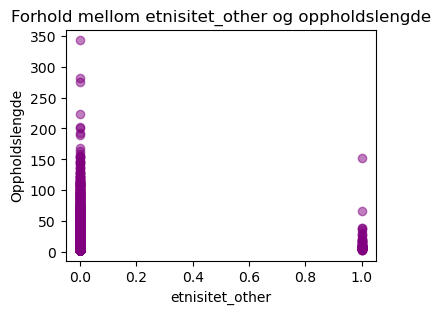

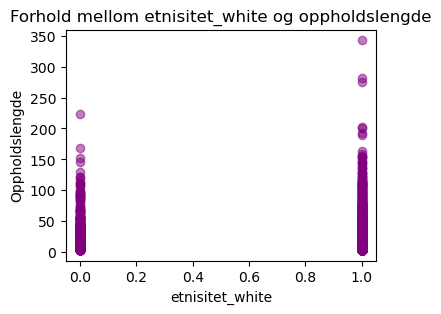

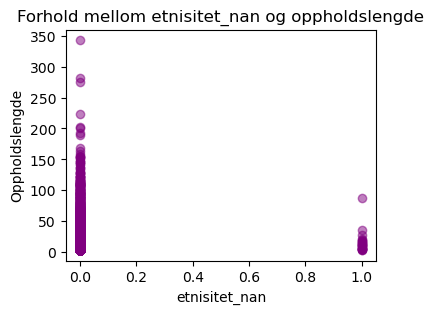

In [22]:
for column in X_train.columns:  
    plt.figure(figsize=(4, 3))
    plt.scatter(X_train_with_target[column], X_train_with_target['oppholdslengde'], alpha=0.5, color='purple')
    plt.xlabel(column)
    plt.ylabel('Oppholdslengde')
    plt.title(f'Forhold mellom {column} og oppholdslengde')
    plt.show()


Disse figurene viser sammenhengen mellom ulike overlevelsesestimater og oppholdslengde for pasientene. Hvert punkt representerer en pasient, og plasseringen viser oppholdslengde (y-aksen) i forhold til estimert overlevelsessannsynlighet etter 2 og 6 måneder, både fra medisinske modeller og legens vurdering. 

Observasjoner: Det ser ikke ut til å være en veldig tydelig lineær eller sterk sammenheng mellom overlevelsesestimater og oppholdslengde. Pasienter med både høye og lave overlevelsesestimater har en variert oppholdslengde, noe som kan tyde på at andre faktorer spiller en større rolle for oppholdslengden. Vi kan på noen av visualiseringene at det er litt sammenheng som på overlevelsesestimat_2mnd. 

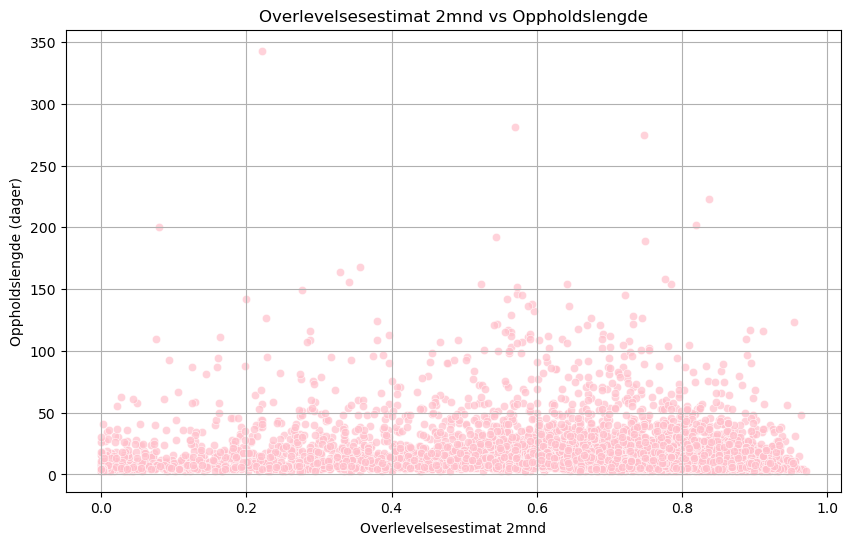

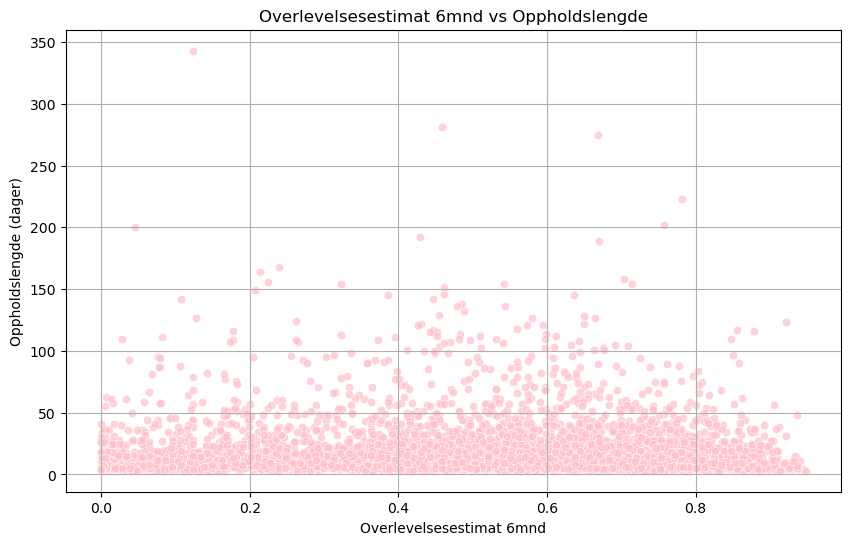

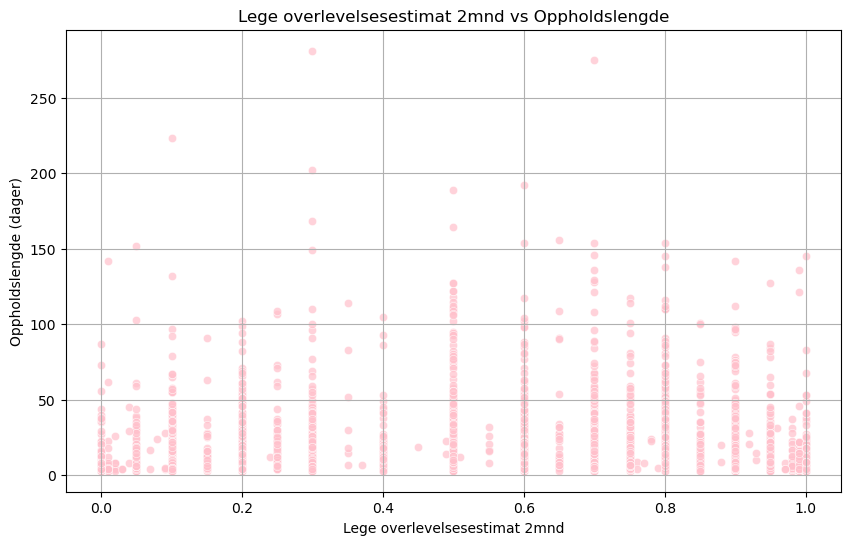

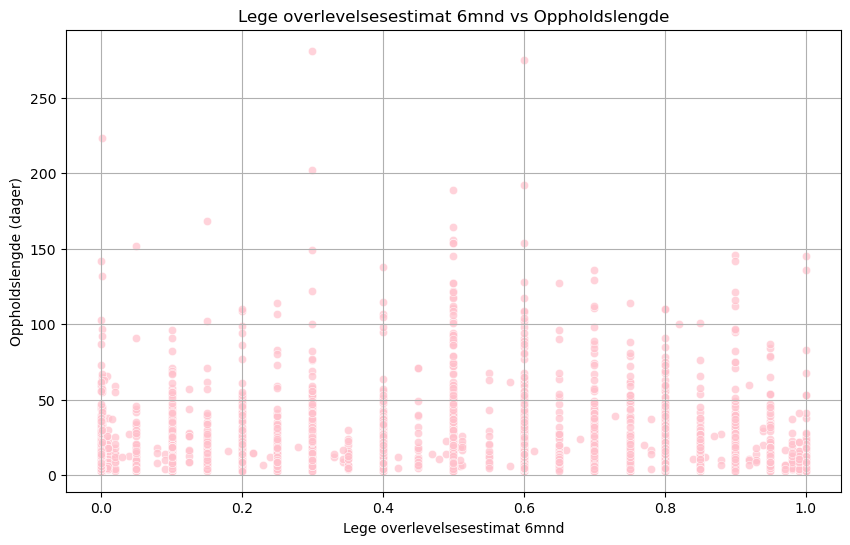

In [23]:
survival_vars = ['overlevelsesestimat_2mnd', 'overlevelsesestimat_6mnd', 
                 'lege_overlevelsesestimat_2mnd', 'lege_overlevelsesestimat_6mnd']

for var in survival_vars:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=var, y='oppholdslengde', data=X_train_with_target, alpha=0.7, color='pink')
    plt.title(f'{var.replace("_", " ").capitalize()} vs Oppholdslengde')
    plt.xlabel(var.replace("_", " ").capitalize())
    plt.ylabel('Oppholdslengde (dager)')
    plt.grid(True)
    plt.show()


Oppholdslengde fordelt på Kjønn
Dette boxplottet viser oppholdslengde for pasienter, fordelt på kjønn. Dataene er delt i to grupper: kjønn_female (kvinner) og kjønn_male (menn), og hvert punkt representerer en pasient.

Observasjoner :Median oppholdslengde ser ut til å være relativt lik mellom kjønnene. Det er flere uteliggere blant både kvinner og menn, noe som indikerer at enkelte pasienter har betydelig lengre opphold enn flertallet. Variasjonen innenfor hver gruppe viser at oppholdslengde kan være påvirket av flere faktorer utover kjønn alene. Noe som vil være naturlig.

In [24]:
gender_column = [
    'kjønn_female',
    'kjønn_male'
]

X_train_with_target = X_train.copy()
X_train_with_target['oppholdslengde'] = y_train.values  

gender_melted = pd.melt(X_train_with_target, id_vars=['oppholdslengde'], value_vars=gender_column, 
                         var_name='sykdom', value_name='Har sykdom')

gender_melted = gender_melted[gender_melted['Har sykdom'] == True]

fig = px.box(gender_melted, x='sykdom', y='oppholdslengde', color='sykdom', width=650, height=500)

fig.update_layout(xaxis={'categoryorder': 'total descending'}, xaxis_title = "Kjønn", legend_title = "Kjønn")


Disse figurene viser forholdet mellom fysiologisk score og APACHE fysiologisk score mot oppholdslengde.

* Observasjoner: 
    * Fysiologisk Score vs. Oppholdslengde: Denne figuren viser hvordan den fysiologiske scoren til pasientene er fordelt i forhold til oppholdslengde. Vi ser at høyere fysiologiske scorer ofte er assosiert med kortere oppholdslengde, noe som kan indikere at pasienter med svært høy score har høy risiko for raskt dødsfall. På den andre enden ser vi at lav score generelt er knyttet til kortere opphold, trolig fordi disse pasientene raskere blir friske. Det mest interessante intervallet er fra 20 til 40 i fysiologisk score, hvor oppholdslengden har en tendens til å være lengre. Dette kan tyde på at pasienter i denne mellomsjiktet trenger lengre tid på å bli friske, da tilstanden kan kreve omfattende behandling uten å nødvendigvis være livstruende.
    * APACHE Fysiologisk Score vs. Oppholdslengde: Figuren viser sammenhengen mellom APACHE fysiologisk score og oppholdslengde. Her ser vi at oppholdslengden er mer jevnt fordelt over ulike score, sammenlignet med den generelle fysiologiske scoren. Pasienter med svært høy APACHE-score har en tendens til kortere opphold, noe som kan indikere en høy risiko for raskt dødsfall. Samtidig har pasienter med lav score også kortere opphold, trolig fordi de blir raskere friske. I mellomsjiktet, mellom 20 og 60, ser vi en mer variert fordeling av oppholdslengde, noe som kan tyde på at pasienter i dette scoreområdet ofte har komplekse medisinske behov som krever lengre tid på sykehuset uten at tilstanden nødvendigvis er livstruende.

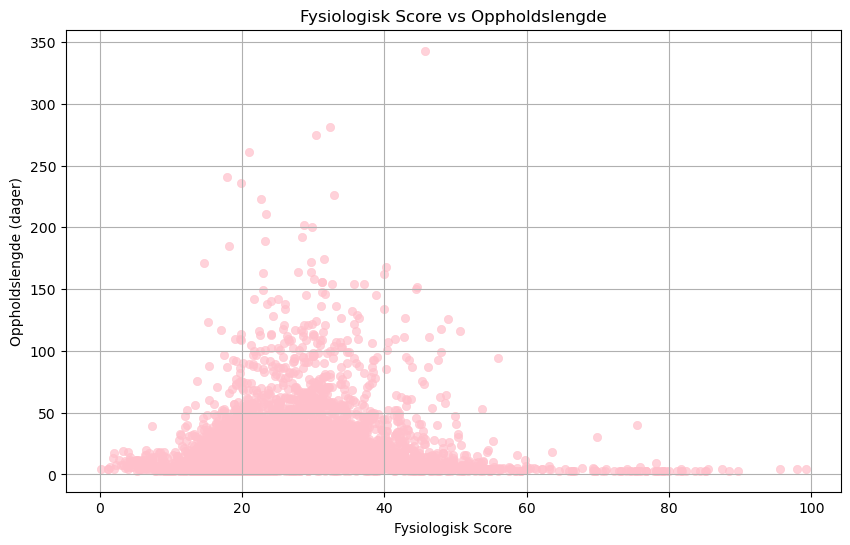

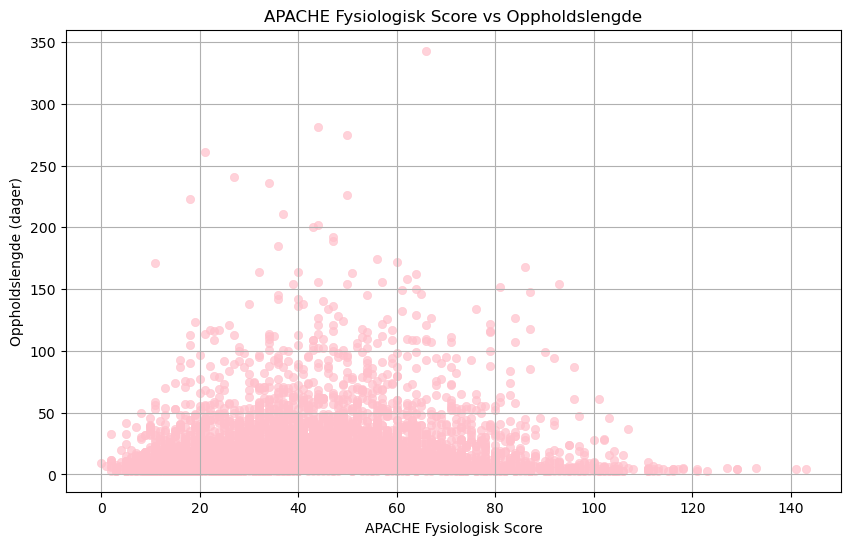

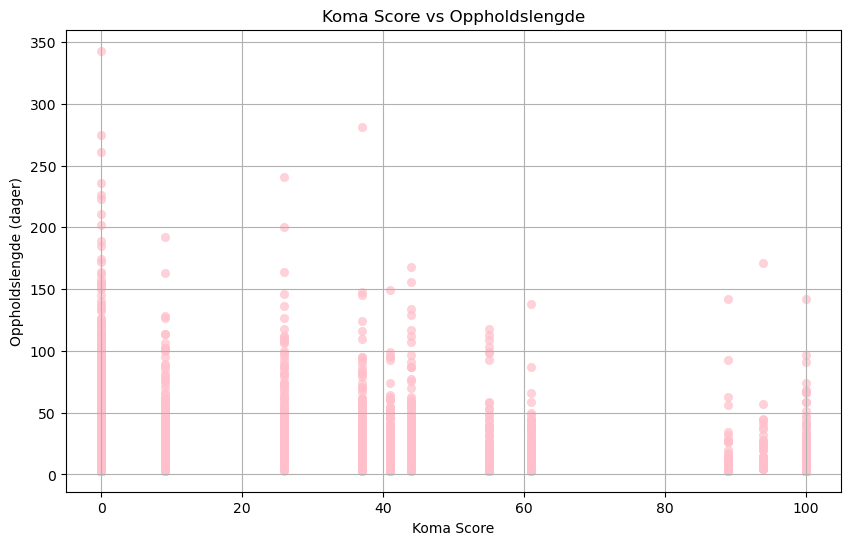

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='fysiologisk_score', y='oppholdslengde', data=df, alpha=0.7,color='pink', edgecolor='pink')
plt.title('Fysiologisk Score vs Oppholdslengde')
plt.xlabel('Fysiologisk Score')
plt.ylabel('Oppholdslengde (dager)')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='apache_fysiologisk_score', y='oppholdslengde', data=df, alpha=0.7, color= 'pink', edgecolor='pink')
plt.title('APACHE Fysiologisk Score vs Oppholdslengde')
plt.xlabel('APACHE Fysiologisk Score')
plt.ylabel('Oppholdslengde (dager)')
plt.grid(True)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='koma_score', y='oppholdslengde', data=df, alpha=0.7, color= 'pink', edgecolor='pink')
plt.title('Koma Score vs Oppholdslengde')
plt.xlabel('Koma Score')
plt.ylabel('Oppholdslengde (dager)')
plt.grid(True)



Dette boxplottet viser oppholdslengden fordelt på forskjellige sykdommer og underkategorier. Hver boks representerer en spesifikk sykdomsgruppe.

* Observasjoner:
    * Median oppholdslengde varierer mellom de ulike sykdommene, noe som kan tyde på at sykdomstype påvirker oppholdslengden.
    * Flere sykdomsgrupper har uteliggere med svært lange opphold. Dette kan indikere at enkelte tilfeller innenfor disse gruppene er spesielt komplekse og krever langvarig behandling.
    * Vi kan se at sykdommer som sepsis, diabetes og kreft pasienter har mest spredning. 

In [26]:

disease_column = [
    'diabetes', 
    'demens', 
    'sykdom_underkategori_ARF/MOSF w/Sepsis', 
    'sykdom_underkategori_CHF', 
    'sykdom_underkategori_COPD', 
    'sykdom_underkategori_Cirrhosis', 
    'sykdom_underkategori_Colon Cancer', 
    'sykdom_underkategori_Coma', 
    'sykdom_underkategori_Lung Cancer', 
    'sykdom_underkategori_MOSF w/Malig', 
    'kreft_metastatic', 
    'kreft_yes'
]

gender_melted = pd.melt(X_train_with_target, id_vars=['oppholdslengde'], value_vars=disease_column, 
                         var_name='sykdom', value_name='Har sykdom')

gender_melted = gender_melted[gender_melted['Har sykdom'] == True]

fig = px.box(gender_melted, x='sykdom', y='oppholdslengde', color='sykdom', width=1300, height=1000)

fig.update_layout(xaxis={'categoryorder': 'total descending'})

fig.show()



Dette plottet viser korrelasjonen mellom variablene i datasettet. Korrelasjon er et mål på sammenhengen mellom to variabler, med verdier mellom -1 og 1. En verdi nær 1 indikerer en sterk positiv korrelasjon, mens en verdi nær -1 indikerer en sterk negativ korrelasjon. En verdi nær 0 indikerer ingen lineær sammenheng.

* Observasjoner:
    * Variabler som er sterkt korrelert vises med sterke røde (positiv) eller blå (negativ) farger.
    * Positiv korrelasjon: Noen variabler, som de ulike overlevelsesestimatene, har høy positiv korrelasjon, noe som tyder på at de kanskje måler lignende aspekter av pasientenes helse.
    * Negativ korrelasjon: Variabler som fysiologisk score og oppholdslengde kan ha negativ korrelasjon med enkelte andre helseparametere.
    * Svake korrelasjoner: Mange variabler viser svak korrelasjon (svake farger), noe som antyder lav lineær sammenheng. Dette kan bety at mange av variablene bidrar med unike aspekter av informasjon uten direkte overlapp.

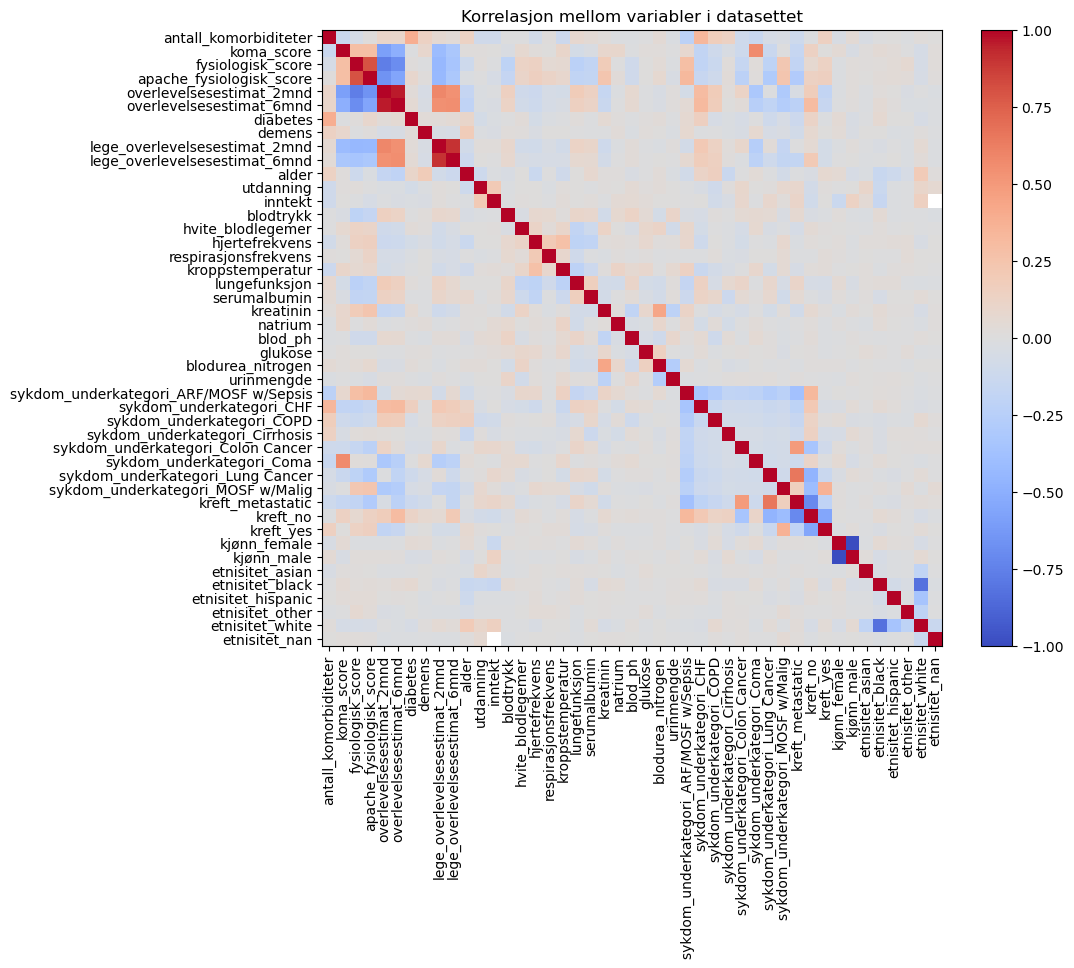

In [27]:
corr_matrix =X_train.corr()

plt.figure(figsize=(10, 8))  
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none', aspect='auto') 
plt.colorbar() 
plt.title('Korrelasjon mellom variabler i datasettet') 

plt.xticks(np.arange(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(np.arange(len(corr_matrix.columns)), corr_matrix.columns)

plt.show()

# Datemodellering

## Fjerning av uteliggere

Jeg ser på boksplottet for å vurdere om det er nødvendig å fjerne uteliggere, og for å få en oversikt over hvor mange og hvor ekstreme disse uteliggerne er i datasettet.

Kom til rap: jeg så først overordnet på alle og bestemte meg for de som påvirket modellen mest på en positivt måte. 

In [28]:
def clip_column(dataframe, column_name, lower_quantile=None, upper_quantile=None):
    lower_bound = dataframe[column_name].quantile(lower_quantile) if lower_quantile is not None else None
    upper_bound = dataframe[column_name].quantile(upper_quantile) if upper_quantile is not None else None
    
    dataframe[column_name] = dataframe[column_name].clip(lower=lower_bound, upper=upper_bound)
    return dataframe

### Urinmengde

In [29]:
fig = px.box(X_train['urinmengde'], title = ('Boxplot for urinmengde'))
fig.update_layout(xaxis_title='urinmengde', yaxis_title='Verdi')
fig.show()

Jeg klipper verdiene i urinmengde ved 25. og 75. prosentilen for å redusere påvirkningen av ekstreme verdier, som kan gi en mer bedre analyse og hindre skjevfordeling i dataene

In [30]:
X_train = clip_column(X_train, "urinmengde", lower_quantile=0.25, upper_quantile=0.75)

### Kreatinin og hvite blodlegemer

In [31]:
fig_kreatinin = px.box(X_train['kreatinin'], y = "kreatinin", title = ('Boxplot for kreatinin'))
fig_kreatinin.update_layout(xaxis_title='kreatinin', yaxis_title='Verdi')
fig_kreatinin.show()

fig_hvite_blodlegemer= px.box(X_train['hvite_blodlegemer'], title = ('Boxplot for hvite blodlegemer'))
fig_hvite_blodlegemer.update_layout(xaxis_title='hvite_blodlegemer', yaxis_title='Verdi')
fig_hvite_blodlegemer.show()

Jeg klipper verdiene i urinmengde ved 95. prosentilen for å redusere påvirkningen av ekstreme verdier, som kan gi en mer bedre analyse og hindre skjevfordeling i dataene

In [32]:

X_train = clip_column(X_train, "kreatinin", upper_quantile=0.95)
X_train = clip_column(X_train, "hvite_blodlegemer", upper_quantile=0.95)



### Blodurea nitrogen og glukose

In [33]:
fig_blodurea_nitrogen = px.box(X_train['blodurea_nitrogen'], title = ('Boxplot for blodurea nitrogen'))
fig_blodurea_nitrogen.update_layout(xaxis_title='Blodurea nitrogen', yaxis_title='Verdi')
fig_blodurea_nitrogen.show()

fig_glukose= px.box(X_train['glukose'], title = ('Boxplot for glukose'))
fig_glukose.update_layout(xaxis_title='glukose', yaxis_title='Verdi')
fig_glukose.show()

Jeg klipper verdiene i urinmengde ved 75. prosentilen for å redusere påvirkningen av ekstreme verdier, som kan gi en mer bedre analyse og hindre skjevfordeling i dataene

In [34]:
X_train = clip_column(X_train, "blodurea_nitrogen", upper_quantile=0.75)
X_train = clip_column(X_train, "glukose", upper_quantile=0.75)

### Må gjøre samme operasjoner for X_val og X_test

In [35]:
X_val = clip_column(X_val, "urinmengde", lower_quantile=0.25, upper_quantile=0.75)
X_val = clip_column(X_val, "kreatinin", upper_quantile=0.95)
X_val = clip_column(X_val, "hvite_blodlegemer", upper_quantile=0.95)
X_val = clip_column(X_val, "blodurea_nitrogen", upper_quantile=0.75)
X_val = clip_column(X_val, "glukose", upper_quantile=0.75)

X_test = clip_column(X_test, "urinmengde", lower_quantile=0.25, upper_quantile=0.75)
X_test = clip_column(X_test, "kreatinin", upper_quantile=0.95)
X_test = clip_column(X_test, "hvite_blodlegemer", upper_quantile=0.95)
X_test = clip_column(X_test, "blodurea_nitrogen", upper_quantile=0.75)
X_test = clip_column(X_test, "glukose", upper_quantile=0.75)


## Feature engineering

Ser først på korrelasjonsmatrise

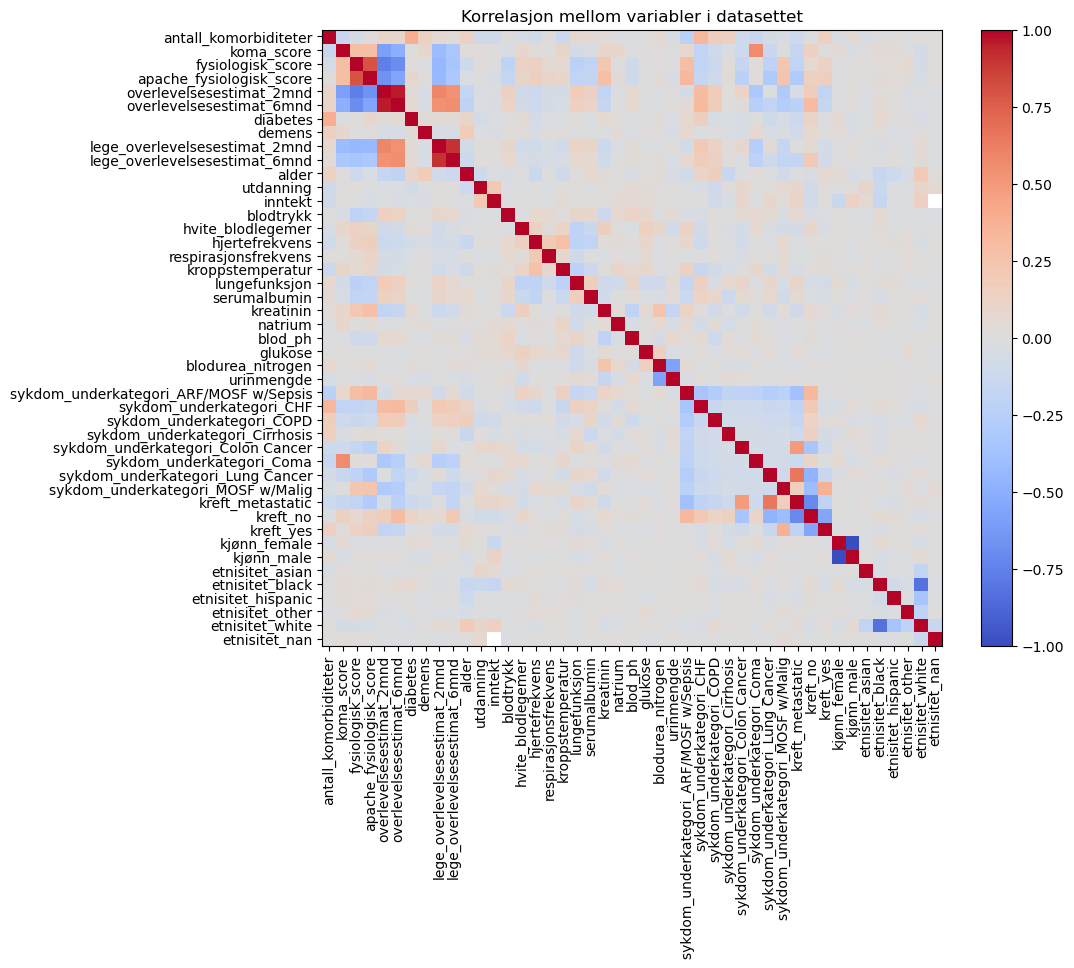

In [36]:
corr_matrix = X_train.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none', aspect='auto')  # Heatmap
plt.colorbar()
plt.title('Korrelasjon mellom variabler i datasettet')

plt.xticks(np.arange(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(np.arange(len(corr_matrix.columns)), corr_matrix.columns)

plt.show() 


Ser at gjennomsnitt overlevelses estimat variablene har mye korrelasjon og det har ogåå koma score og fysiologisk score. Lager dermed en ny korrelasjonmatrise for disse. 

Korrelasjon mellom utvalgte variabler
Dette plottet viser korrelasjonen mellom et utvalg variabler, inkludert ulike overlevelsesestimat, fysiologisk score og koma score. Korrelasjonsverdiene er indikert ved farger fra blått (negativ korrelasjon) til rødt (positiv korrelasjon), med verdier mellom -1 og 1.
* Observasjoner:
    * Sterk positiv korrelasjon: 
        * Lege- og modellbaserte overlevelsesestimat: Vi ser en høy korrelasjon (opptil 0.96) mellom overlevelsesestimater på 2 og 6 måneder, både for modellbaserte estimater og legens vurderinger.Dette tyder på at både modellene og legene har en lignende vurdering av pasientens overlevelsessannsynlighet over tid.
        * Lege- og modellbaserte 6-måneders estimater: Korrelasjonen mellom legens 6-måneders overlevelsesestimat og modellens 6-måneders estimat er også sterk (0.90).
    * Negativ korrelasjon:
        * Overlevelsesestimater og fysiologisk score: Det er en moderat negativ korrelasjon mellom overlevelsesestimatene og fysiologisk score, noe som kan tyde på at høyere fysiologiske scorer (alvorligere tilstand) er forbundet med lavere overlevelsessannsynlighet.
        * Koma score og overlevelsesestimat: Koma scoren viser også en negativ korrelasjon med overlevelsesestimater, noe som er forventet siden en høyere koma score vanligvis indikerer en dårligere prognose.
        

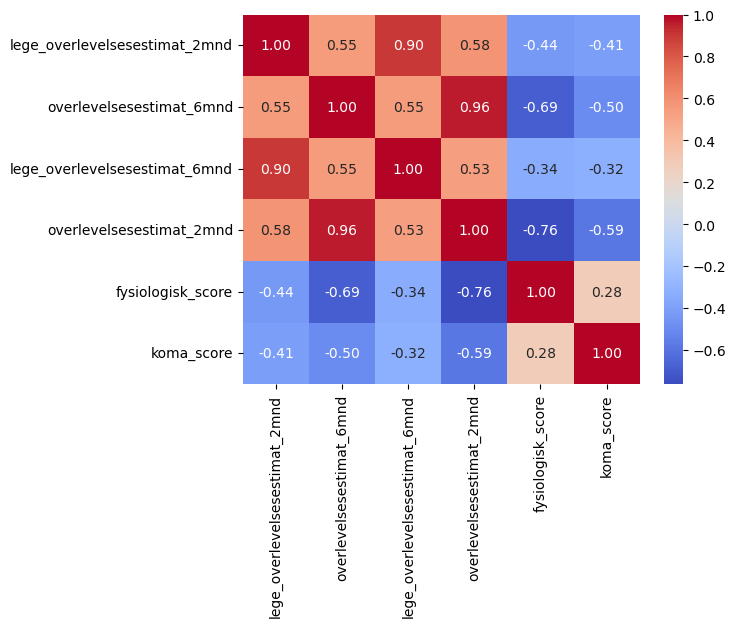

In [37]:
g = sns.heatmap(X_train[["lege_overlevelsesestimat_2mnd", "overlevelsesestimat_6mnd", 
                              "lege_overlevelsesestimat_6mnd", "overlevelsesestimat_2mnd", 
                              "fysiologisk_score", "koma_score"]].corr(),annot=True, fmt = ".2f", cmap = "coolwarm")

Grunnet høy korrelasjon og observasjoner fra tidligere visulaiseringer på fysiologisk_score og koma_score oppretter jeg tre nye variabler

In [38]:
X_train['tidlig_overlevelsesestimat_gjennomsnitt'] = (X_train['lege_overlevelsesestimat_2mnd'] + X_train['overlevelsesestimat_6mnd']) / 2
X_val['tidlig_overlevelsesestimat_gjennomsnitt'] = (X_val['lege_overlevelsesestimat_2mnd'] + X_val['overlevelsesestimat_6mnd']) / 2
X_test['tidlig_overlevelsesestimat_gjennomsnitt'] = (X_test['lege_overlevelsesestimat_2mnd'] + X_test['overlevelsesestimat_6mnd']) / 2


X_train['sen_overlevelsesestimat_gjennomsnitt'] = (X_train['lege_overlevelsesestimat_6mnd'] + X_train['overlevelsesestimat_2mnd']) / 2
X_val['sen_overlevelsesestimat_gjennomsnitt'] = (X_val['lege_overlevelsesestimat_6mnd'] + X_val['overlevelsesestimat_2mnd']) / 2
X_test['sen_overlevelsesestimat_gjennomsnitt'] = (X_test['lege_overlevelsesestimat_6mnd'] + X_test['overlevelsesestimat_2mnd']) / 2


X_train['helsetilstand'] = X_train['fysiologisk_score'] * X_train['koma_score']
X_val['helsetilstand'] = X_val['fysiologisk_score'] * X_val['koma_score']
X_test['helsetilstand'] = X_test['fysiologisk_score'] * X_test['koma_score']


## Baseline

Denne koden oppretter en baseline-modell ved hjelp av DummyRegressor, som bruker gjennomsnittlig verdi fra treningssett til å gjøre prediksjoner. Formålet med baseline-modellen er å gi et enkelt referansepunkt for vurdering av mer avanserte modeller.

In [39]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
prediction = baseline.predict(X_val)
rmse_baseline = root_mean_squared_error(y_val, prediction)
print(prediction)
rmse_baseline

[17.90924214 17.90924214 17.90924214 ... 17.90924214 17.90924214
 17.90924214]


18.683613878347693

## Valg av modell

Denne koden utfører en evaluering av ulike modeller og metoder for håndtering av manglende data (imputasjon) for å predikere oppholdslengde.

* Imputasjonsstrategier: Flere metoder for å fylle inn manglende data testes, inkludert gjennomsnitt, median, mest most frequent og KNN med forskjellige antall neighbours.
* Modeller: Forskjellige regresjonsmodeller, som RandomForestRegressor, Lasso, MLPRegressor, og GradientBoostingRegressor, trenes på datasett med hver imputasjonsstrategi.
* Evaluering: For hver kombinasjon beregnes RMSE på valideringssettet. Kombinasjonen med lavest RMSE identifiseres som den beste.

In [40]:
imputation_strategies = {
    "mean_imputer": SimpleImputer(strategy='mean'),
    "knn_imputer 50": KNNImputer(n_neighbors=50),
    "knn_imputer 10": KNNImputer(n_neighbors=10),
    "knn_imputer 100": KNNImputer(n_neighbors=100),
    "knn_imputer 150": KNNImputer(n_neighbors=150),
    "median_imputer": SimpleImputer(strategy='median'),
    "most_frequent_imputer": SimpleImputer(strategy='most_frequent')
}

filled_X_train = {key: imputer.fit_transform(X_train) for key, imputer in imputation_strategies.items()}
filled_X_val = {key: imputer.transform(X_val) for key, imputer in imputation_strategies.items()}

models = {
    'RandomForestRegressor1': RandomForestRegressor(random_state=42),
    'RandomForestRegressor2': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'RandomForestRegressor3': RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_split=5, random_state=42),
    
    'Lasso_1.0': Lasso(alpha=1.0),
    'Lasso_0.1': Lasso(alpha=0.1),
    'Lasso_0.01': Lasso(alpha=0.01),

    'MLPRegressor1': MLPRegressor(random_state=42),
    'MLPRegressor2': MLPRegressor(hidden_layer_sizes=(50,), learning_rate_init=0.01, max_iter=500, random_state=42),

    'GradientBoosting1': GradientBoostingRegressor(random_state=42),
    'GradientBoosting_1': GradientBoostingRegressor(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42)
}

rmse_scores = {}

for model_name, model in models.items():
    for strategy_name, X_train_imputed in filled_X_train.items():
        X_val_imputed = filled_X_val[strategy_name]
        model.fit(X_train_imputed, y_train)
        predictions = model.predict(X_val_imputed)
        rmse = root_mean_squared_error(y_val, predictions)
        print(f"Model: {model_name}, Imputation: {strategy_name}, RMSE: {rmse:.4f}")
        rmse_scores[(model_name, strategy_name)] = rmse

best_combination = min(rmse_scores, key=rmse_scores.get)
best_model_name, best_strategy_name = best_combination
best_rmse = rmse_scores[best_combination]

print(f"\nOverall best result:")
print(f"Best Model: {best_model_name}")
print(f"Best Imputation Strategy: {best_strategy_name}")
print(f"Best Validation RMSE: {best_rmse:.4f}")





Model: RandomForestRegressor1, Imputation: mean_imputer, RMSE: 18.3193
Model: RandomForestRegressor1, Imputation: knn_imputer 50, RMSE: 18.3115
Model: RandomForestRegressor1, Imputation: knn_imputer 10, RMSE: 18.5734
Model: RandomForestRegressor1, Imputation: knn_imputer 100, RMSE: 18.5663
Model: RandomForestRegressor1, Imputation: knn_imputer 150, RMSE: 18.5172
Model: RandomForestRegressor1, Imputation: median_imputer, RMSE: 18.4145
Model: RandomForestRegressor1, Imputation: most_frequent_imputer, RMSE: 18.5971
Model: RandomForestRegressor2, Imputation: mean_imputer, RMSE: 17.8555
Model: RandomForestRegressor2, Imputation: knn_imputer 50, RMSE: 17.7770
Model: RandomForestRegressor2, Imputation: knn_imputer 10, RMSE: 17.8806
Model: RandomForestRegressor2, Imputation: knn_imputer 100, RMSE: 17.9315
Model: RandomForestRegressor2, Imputation: knn_imputer 150, RMSE: 17.8546
Model: RandomForestRegressor2, Imputation: median_imputer, RMSE: 17.7847
Model: RandomForestRegressor2, Imputation: m

## Lagrer modellen som best model

In [41]:
best_imputer = imputation_strategies[best_strategy_name]
X_train_imputed = best_imputer.fit_transform(X_train)

best_model = models[best_model_name]
best_model.fit(X_train_imputed, y_train)

GradientBoostingRegressor(n_estimators=50, random_state=42)

## Feature importance

Denne koden beregner og visualiserer viktigheten til hver variabel i modellen.

* Beregning av variabelviktighet: feature importance  hentes fra den beste modellen og kombineres med kolonnenavnene i en DataFrame.
* Sortering: Variablene sorteres etter viktighet i stigende rekkefølge.
* Visualisering: En horisontal stolpediagram viser viktigheten til hver variabel, der de mest viktige variablene er lengst mot toppen.

Dette gir informasjon om hvilke variabler som har størst påvirkning på modellens prediksjoner

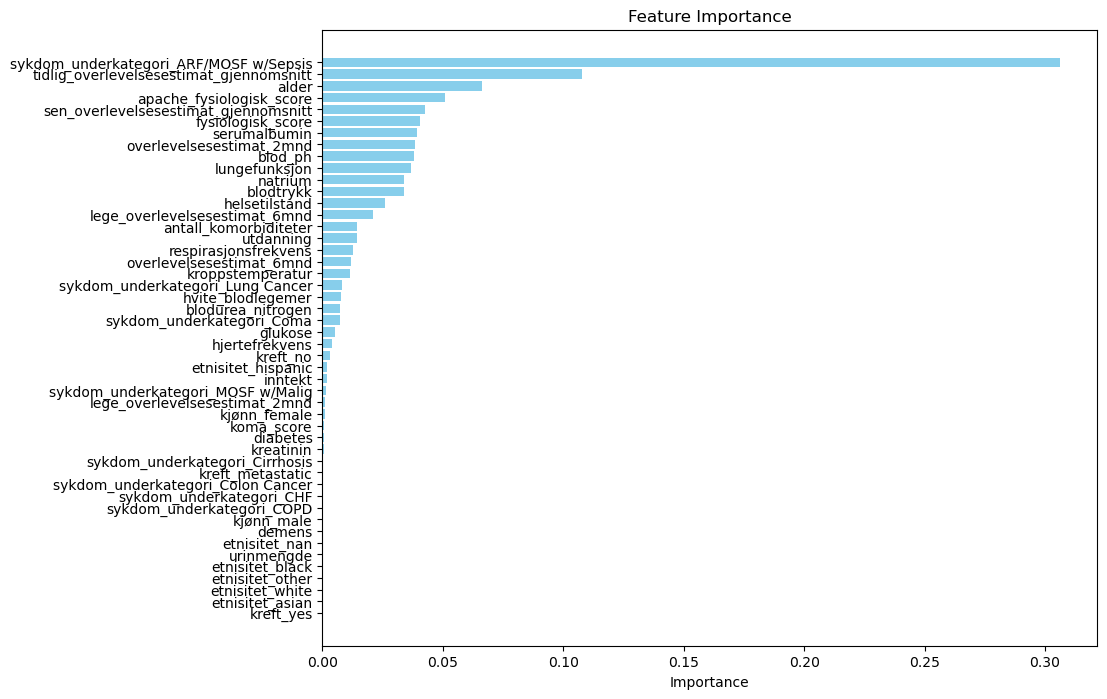

In [42]:
importances = best_model.feature_importances_

feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()

Denne koden fjerner variabler med lav betydning for modellen og evaluerer ytelsen på nytt.

* Identifisering av lav viktighet: Variabler med en viktighet ≤ 0.006 identifiseres som mindre relevante og lagres i en liste (low_importance_features).
* Fjerning av lav viktighet: Disse variablene fjernes fra trenings-, validerings- og testsettet for å redusere modellens kompleksitet.
* Det kommer frem at dette ikke hjelper modellen, derfor går jeg ikke videre med det

In [43]:
low_importance_features = feature_importance_df[feature_importance_df['Importance'] <= 0.006]['Feature'].tolist()

print("Funksjoner med lav verdi for modellen:", low_importance_features)
print("Antall funksjoner med lav importance:", len(low_importance_features))

X_train_reduced = X_train.drop(columns=low_importance_features)
X_val_reduced = X_val.drop(columns=low_importance_features)
X_test_reduced = X_test.drop(columns=low_importance_features)

best_imputer = imputation_strategies[best_strategy_name]
X_train_imputed = pd.DataFrame(best_imputer.fit_transform(X_train_reduced), columns=X_train_reduced.columns)
X_val_imputed = pd.DataFrame(best_imputer.transform(X_val_reduced), columns=X_val_reduced.columns)


best_model.fit(X_train_imputed, y_train)


y_val_pred = best_model.predict(X_val_imputed)
rmse_val = root_mean_squared_error(y_val, y_val_pred)

print(f"RMSE på Valideringssett med Reduserte Funksjoner: {rmse_val:.4f}")

Funksjoner med lav verdi for modellen: ['kreft_yes', 'etnisitet_asian', 'etnisitet_white', 'etnisitet_other', 'etnisitet_black', 'urinmengde', 'etnisitet_nan', 'demens', 'kjønn_male', 'sykdom_underkategori_COPD', 'sykdom_underkategori_CHF', 'sykdom_underkategori_Colon Cancer', 'kreft_metastatic', 'sykdom_underkategori_Cirrhosis', 'kreatinin', 'diabetes', 'koma_score', 'kjønn_female', 'lege_overlevelsesestimat_2mnd', 'sykdom_underkategori_MOSF w/Malig', 'inntekt', 'etnisitet_hispanic', 'kreft_no', 'hjertefrekvens', 'glukose']
Antall funksjoner med lav importance: 25
RMSE på Valideringssett med Reduserte Funksjoner: 17.1919


Observasjoner: Ser at modellen ikke blir noe bedre av å fjerne noen variabler. Derfor velger jeg å ikke fjerne noen.

# Generaliseringevne

Denne koden bruker den beste imputasjonsstrategien og den beste modellen for å evaluere ytelsen på både validerings- og testsett.

* Imputasjon: Den valgte imputasjonsstrategien best_imputer brukes til å fylle inn manglende verdier i trenings-, validerings- og testsettet.
* Trening: Modellen trenes på det imputerte treningssettet.
* Evaluering på valideringssettet: Prediksjoner gjøres på valideringssettet, og RMSE beregnes for å måle ytelsen.
* Evaluering på testsettet: Prediksjoner gjøres på testsettet, og RMSE beregnes for å få et endelig ytelsesmål.

In [44]:
imputer = best_imputer
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_val_imputed = pd.DataFrame(imputer.transform(X_val), columns=X_val.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Tren modellen på treningssettet
best_model.fit(X_train_imputed, y_train)

# Beregn RMSE på valideringssettet
y_val_pred = best_model.predict(X_val_imputed)
rmse_val = root_mean_squared_error(y_val, y_val_pred)
print(f"RMSE på Valideringssett: {rmse_val:.4f}")

# Beregn RMSE på testsettet
y_test_pred = best_model.predict(X_test_imputed)
rmse_test = root_mean_squared_error(y_test, y_test_pred)
print(f"RMSE på Testsett: {rmse_test:.4f}")

RMSE på Valideringssett: 17.1311
RMSE på Testsett: 23.6862


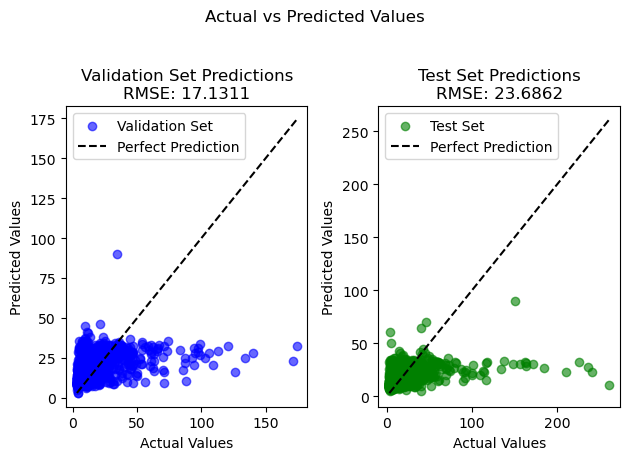

In [45]:
plt.subplot(1, 2, 1)
plt.scatter(y_val, y_val_pred, color='blue', alpha=0.6, label='Validation Set')
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], 'k--', label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Validation Set Predictions\nRMSE: {root_mean_squared_error(y_val, y_val_pred):.4f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, color='green', alpha=0.6, label='Test Set')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Test Set Predictions\nRMSE: {root_mean_squared_error(y_test, y_test_pred):.4f}')
plt.legend()

plt.suptitle('Actual vs Predicted Values')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

plt.show()

# Nettside

In [46]:
model_and_imputer = {
    'model': best_model,
    'imputer': imputer
}

with open('model_with_imputer.pkl', 'wb') as file:
    pickle.dump(model_and_imputer, file)
    